<p align="center">
<img src="Images/sorbonne_logo.png" alt="Logo" width="300"/>
</p>

# **Module 4 - Hsu et al. (2021) Replication**

* **Author**: Elia Landini
* **Student ID**: 12310239
* **Course**: EESM2-Financial Economics 
* **Supervisor**: Jean-Bernard Chatelain
* **Reference Repository**: https://github.com/EliaLand/Policy_Target_RegimeSwitchingPersistence

### **1) REQUIREMENTS SET-UP**

In [39]:
# Requirements.txt file installation
# !pip install -r requirements.txt

In [40]:
# Libraries import
import warnings
import pandas as pd
import numpy as np
import numpy.linalg as la
import random
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle
import matplotlib.patches as mpatches
import plotly.graph_objects as go
%matplotlib inline
from itertools import combinations
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import levene
from scipy.stats import ks_2samp
from scipy.stats import kstest
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.api import VAR
from scipy.linalg import eigvals, cholesky
from sklearn.decomposition import PCA

### **2) DATA PREP & FACTOR EXTRACTION**

In [41]:
# Df import 
# (!!!) We use stationary transformed variables, both policy target, like usual and LogDiff transformed policy instrument ("LogDiff-Call Money/Interbank Immediate (%)")
jp_trans_df = pd.read_csv("Data/Transformed/jp_trans_df.csv")

df = jp_trans_df.copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time")
# (!!!) Remember to take those -inf or inf values out
df = df.replace([np.inf, -np.inf], np.nan)

In [42]:
# Variables Filtering for Factors Construction
# (!!!) We keep only time as index, and relevant variables, we exclude "Coutry", as well as other target variables proxies  
# (!!!) Policy Target: LogDiff-HICP (SA) Policy Instrument: LogDiff-Call Money/Interbank Immediate (%)
favar_vars = [col for col in df.columns if col not in ["Country", "AR(1)detrend-Call Money/Interbank Immediate (%)"]]
favar_df = df[favar_vars].dropna().copy()

favar_df

,LogDiff-Monetary Aggregates - M1 (JPY),LogDiff-Monetary Aggregates - M2 (JPY),LogDiff-Monetary Aggregates - M3 (JPY),LogDiff-Total Treasury Reserves (- Gold),LogDiff-USD-JPY reer CPI-based (Index 2015=100),LogDiff-JPY-USD Spot Exchange Rate,LogDiff-HICP (SA),LogDiff-1615.T-Price,LogDiff-BoJ’s Total Assets (100 Million Yen),LogDiff-Call Money/Interbank Immediate (%),...,AR(1)detrend-Est. 1-year Neutral Interest Rate (%),AR(1)detrend-Est. 10-year Neutral Interest Rate (%),AR(1)detrend-Central Government Debt (% GDP),AR(1)detrend-Domestic Private Debt Securities (% GDP),AR(1)detrend-Domestic Public Debt Securities (% GDP),AR(1)detrend-Loan Interest Rate (%),AR(1)detrend-Deposit Interest Rate (%),AR(1)detrend-10-Year US T-Bills Yield (%),AR(1)detrend-CBOE-VIX,HPfilter-Real GDP (billions chained 2015 JPY)
Time,,,,,,,,,,,,,,,,,,,,,
2008-02-01,-0.001999,0.002594,0.000775,0.010984,-0.012341,-0.007336,1.028915,-0.078154,0.010447,0.003976,...,0.004194,0.004743,-0.424575,0.355688,-0.441633,0.041879,0.060165,-0.016004,0.605666,0.013236
2008-03-01,-0.002515,0.000898,-0.000097,0.008642,0.050226,-0.060405,1.111576,-0.088370,-0.007216,0.013793,...,0.004194,0.004743,-0.424575,0.355688,-0.441633,0.080813,0.014681,-0.236748,2.558529,0.015619
2008-04-01,-0.005934,-0.001847,-0.002132,-0.010342,-0.030758,0.018891,-2.448252,0.247112,-0.056246,-0.009833,...,-0.058806,-0.076257,-0.424575,0.355688,-0.441633,-0.005028,-0.075822,0.154748,-4.378964,0.013480
2008-05-01,0.001221,0.003369,0.001841,-0.007380,-0.008490,0.016247,8.137150,-0.012722,0.026731,-0.001978,...,0.004046,0.004518,-0.424575,0.355688,-0.441633,-0.059705,0.038243,0.195476,-2.940991,0.016428
2008-06-01,0.003667,0.003100,0.002514,0.003562,-0.024539,0.024194,8.184920,-0.114273,-0.082368,0.007890,...,0.004046,0.004518,-0.424575,0.355688,-0.441633,0.133879,0.009457,0.210904,3.629407,0.019618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-10-01,0.004251,0.002236,0.001796,-0.004449,-0.010298,-0.000828,-2.383439,0.069958,0.020079,0.133531,...,-0.020583,-0.025225,-0.410443,-0.212035,-0.320379,-0.061186,0.006111,-0.119005,-6.840790,-0.001223
2015-11-01,0.002978,0.001994,0.001630,-0.007613,-0.014733,0.021387,-2.837811,-0.009050,0.020405,0.000000,...,0.003360,0.003694,-0.410443,-0.212035,-0.320379,0.096139,0.001628,0.176557,-0.987707,-0.002095
2015-12-01,0.003291,0.001658,0.002146,0.000141,0.012087,-0.008255,1.239080,-0.027652,0.004850,-0.133531,...,0.003360,0.003694,-0.410443,-0.212035,-0.320379,-0.004414,0.005614,-0.036180,1.319075,-0.002955


In [43]:
# PCA (Data Comopression)
# (!!!) We can't find 23 variables into a VAR, or it would lead to degrees of freedom issue, so we use pca to create 5 super factors (variables) to plug in
# (!!!) These Factors summarize everything a CB has control on or can monitor
# (!!!) F1-F5 are UNCORRELATED (no multicollinearity), from 23 variables, to 5 uncorrelated 

# 5 factors PCA
pca = PCA(n_components=5) 
pca5_factors = pca.fit_transform(favar_df.values)

# Factors numbering 
factors_df = pd.DataFrame(
    pca5_factors, 
    index=favar_df.index, 
    columns=[f"F{i+1}" for i in range(5)]
)

# (!!!) Explained variance 
# (!!!) cumulative sum by adding one factor at a time of how much info we kept, the biggest jump is from 1 to 2 factors
print("Explained variance:", pca.explained_variance_ratio_.cumsum())

Explained variance: [0.39087879 0.63102504 0.81881692 0.94290269 0.98256597]


### **3) Y TARGET VARIABLES & SMOOTHING VARIABLE Z**

In [44]:
# Target Variables Y
Y_vars = [
# Policy Target 
    "LogDiff-HICP (SA)",   
# Policy Instrument   
    "LogDiff-Call Money/Interbank Immediate (%)"
]
# Target Variables Aggregation
# (!!!) Forward filling of nan 
Y = df[Y_vars].reindex(factors_df.index).fillna(method="ffill")

# Final FVAR df
# P_t = [Y1,Y2, F1,F2,F3,F4,F5]
favar_core_df = pd.concat([Y, factors_df], axis=1).dropna()
favar_core_df

C:\Users\eland\AppData\Local\Temp\ipykernel_2560\3005071284.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Y = df[Y_vars].reindex(factors_df.index).fillna(method="ffill")


,LogDiff-HICP (SA),LogDiff-Call Money/Interbank Immediate (%),F1,F2,F3,F4,F5
Time,,,,,,,
2008-02-01,1.028915,0.003976,0.297209,-0.417214,0.982228,-0.537485,-0.788507
2008-03-01,1.111576,0.013793,2.222868,-0.342918,1.191742,-0.299188,-0.850719
2008-04-01,-2.448252,-0.009833,-4.223446,0.234701,-2.474074,-2.194426,-1.028600
2008-05-01,8.137150,-0.001978,-3.802970,-2.323139,7.230291,1.222328,-0.093392
2008-06-01,8.184920,0.007890,2.685884,-2.019418,7.732483,1.962555,-0.304962
...,...,...,...,...,...,...,...
2015-10-01,-2.383439,0.133531,-6.765654,0.277571,-2.798076,-2.083223,0.491286
2015-11-01,-2.837811,0.000000,-0.983467,0.556379,-2.737426,-1.629910,-0.647473
2015-12-01,1.239080,-0.133531,0.958176,-0.327301,1.142983,-0.142556,-0.394840


In [45]:
# AIC for lag order selection 
model = VAR(Y)
lag_order = model.select_order(maxlags=10)
print(lag_order.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -1.689     -1.632*      0.1848     -1.666*
1      -1.714*      -1.544     0.1801*      -1.646
2       -1.668      -1.384      0.1887      -1.554
3       -1.581      -1.184      0.2059      -1.421
4       -1.580      -1.070      0.2063      -1.375
5       -1.512     -0.8884      0.2211      -1.261
6       -1.491     -0.7536      0.2263      -1.194
7       -1.435     -0.5847      0.2398      -1.093
8       -1.379     -0.4154      0.2544     -0.9911
9       -1.340     -0.2628      0.2657     -0.9061
10      -1.291     -0.1010      0.2803     -0.8121
--------------------------------------------------


d:\Conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [46]:
# Smoothing Varible - Regime Indicator 
# (!!!) We can use the lag of the policy intrument to define whether the VAR runs under a monetary policy period of tightness or looseness, or like under ycc
# (!!!) Comments to be made especially during the period of YCC

# 6 Lags Interbank Rate - Smoothing Variable
# (!!!) Instantaneous Interbank rate target variable (Y)
Z = favar_core_df["LogDiff-Call Money/Interbank Immediate (%)"].shift(6).dropna()  
reg_favar_core_df = favar_core_df.loc[Z.index]

# Low-High Policy Regimes
# (!!!) As in the paper, we identify 4 policy regimes 
z_grid = np.percentile(Z, [20,40,60,80])  
z_grid

array([-0.04495139, -0.00983292,  0.        ,  0.02531781])

### **4) LOCAL FAVAR**

In [47]:
# Local FAVAR
# (!!!) Optimal Lag Order from AIC Order Selection
lag = 2
K = favar_core_df.shape[1]
results = {}

for i, z0 in enumerate(z_grid):
# Local weights 
# (!!!) We rescale through local weights the different regions of the Z smoothing factor to prioritize observations close to zero
    h = 0.1 * np.std(Z)
# Gaussian Rescaling
    kern = np.exp(-0.5 * ((Z - z0)/h)**2) / (h * np.sqrt(2 * np.pi))
    K_w = kern.iloc[1:].values / kern.iloc[1:].sum()


# VAR data
# Smoothing factor
    wvar_data = reg_favar_core_df.values[1:]
    n = wvar_data.shape[0]
# Regressors and target
    X = np.ones((n - lag, (lag + 1) * K))
    y_list = []
# Lag Matrix X
    for t in range(lag, n):
        y_list.append(wvar_data[t])
        for q in range(1, lag + 1):
            X[t - lag, q*K:(q+1)*K] = wvar_data[t - q]
    y = np.array(y_list)
    weights = np.diag(np.sqrt(K_w[lag:]))


# Rescaled Weighted OLS
    X_w = weights @ X
    y_w = weights @ y
    beta = la.pinv(X_w.T @ X_w) @ (X_w.T @ y_w)
# Reshaping to VAR matrices
    Phi_z0 = beta.reshape(lag + 1, K, K)
    results[z0] = Phi_z0

    print(f"z0={z0:.3f}: AR(1) diags {np.diag(Phi_z0[1])[:4].round(3)}...")

print("Roots check (avg A1):", np.abs(eigvals(np.mean([r[1] for r in results.values()],0))))

z0=-0.045: AR(1) diags [-1.52612e+02 -8.20000e-02 -2.95400e+00  4.80820e+01]...
z0=-0.010: AR(1) diags [-47.978   0.086   3.102 -21.066]...
z0=0.000: AR(1) diags [-43.011   0.11    1.331 -34.445]...
z0=0.025: AR(1) diags [-3.5945e+01  2.6000e-02  4.7820e+00 -1.3557e+01]...
Roots check (avg A1): [0.58166308 0.58166308 0.45805053 0.32619123 0.32619123 0.22554829
 0.14878299]


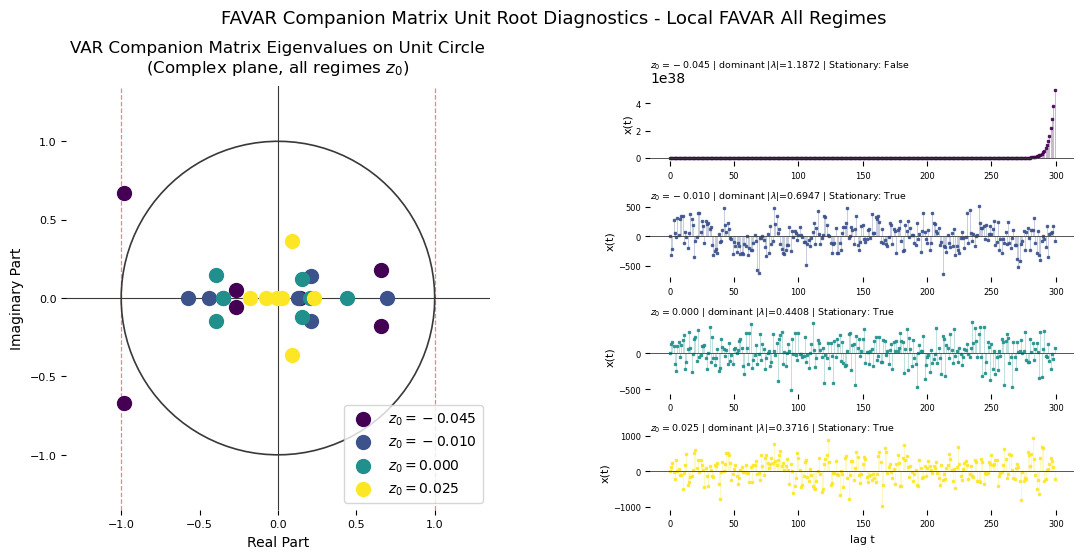

In [48]:
# FAVAR Companion-Matrix Unit-Root Circle Plotting

# General settings & Parameters
# We extract eigenvalues and parameters from the Local FAVAR estimated companion matrices
core_variables = [f"$z_0={z0:.3f}$" for z0 in z_grid]
# Eigenvalues of Phi_1 companion matrix for each regime
eigenvalues_per_regime = {z0: eigvals(results[z0][1]) for z0 in z_grid}
# Dominant eigenvalue (largest modulus) per regime — VAR analog of AR(1) coefficient
dominant_eigs = np.array([
    eigenvalues_per_regime[z0][np.argmax(np.abs(eigenvalues_per_regime[z0]))]
    for z0 in z_grid
])
# Stationarity flag: all eigenvalues inside unit circle
stationary = [
    all(np.abs(eigenvalues_per_regime[z0]) < 1.0) for z0 in z_grid
]
# Angle of the circle
theta = np.linspace(0, 2 * np.pi, 100)
# Color Palette
palette = ["#440154", "#3B528B", "#21908C", "#FDE725"]
colors  = [palette[i % len(palette)] for i in range(len(core_variables))]
# Figure settings
fig = plt.figure(figsize=(13, 5.5), facecolor="#ffffff")
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.38)


# Unit Root Circle
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor("#ffffff")

# Plot components:
# 1) Unit circle
ax1.plot(np.cos(theta), np.sin(theta), color="#393939", lw=1.2, zorder=1)
# 2) Vertical and horizontal axes (0,0)
ax1.axhline(0, color="#393939", lw=0.8, zorder=0)
ax1.axvline(0, color="#393939", lw=0.8, zorder=0)
# 3) +1, -1 Vertical Stationarity limits (-1, +1)
ax1.axvline(1.0,  color="#ff0000", lw=0.9, linestyle="--", alpha=0.5, zorder=0)
ax1.axvline(-1.0, color="#ff0000", lw=0.9, linestyle="--", alpha=0.5, zorder=0)

# Variables lambda on the circle
# VAR eigenvalues can be complex — plot real vs imaginary parts in the complex plane
for i, (z0, var, col) in enumerate(zip(z_grid, core_variables, colors)):
    eigs = eigenvalues_per_regime[z0]
# (!!!) To plot the lambda point we can use the scatter function
    ax1.scatter(eigs.real, eigs.imag,
                color=col, s=100, zorder=4, linewidths=1.0, label=var)

# Subplot settings
# (!!!) Set .set_aspect to "equal" and not "auto" or it deforms the unit root circle into an ellipse
ax1.set_xlim(-1.35, 1.35)
ax1.set_ylim(-1.35, 1.35)
ax1.set_aspect("equal")
ax1.set_title("VAR Companion Matrix Eigenvalues on Unit Circle\n(Complex plane, all regimes $z_0$)", pad=10)
ax1.set_xlabel("Real Part")
ax1.set_ylabel("Imaginary Part")
ax1.tick_params(labelsize=8)
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.legend(loc="lower right")


# Simulated FAVAR processes
# Grid settings
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.38)
gs_right = gridspec.GridSpecFromSubplotSpec(
    len(core_variables), 1,
    subplot_spec=gs[1],
    hspace=0.55
)

# Simulation Parameters
# Random seed
np.random.seed(42)
# Number of steps to simulate
N = 300
K = favar_core_df.shape[1]

# Simulation Plotting
for i, (z0, var, col, stat) in enumerate(zip(z_grid, core_variables, colors, stationary)):
    ax = fig.add_subplot(gs_right[i])
    ax.set_facecolor("#ffffff")
    Phi1 = results[z0][1]
    Phi2 = results[z0][2]
# Simulation of the VAR(2) process: y_t = Phi1 @ y_{t-1} + Phi2 @ y_{t-2} + u_t
# We plot the first variable's trajectory as representative
    eps = np.random.normal(0, 1, (N, K))
    Y = np.zeros((N, K))
    Y[0] = eps[0]
    Y[1] = Phi1 @ Y[0] + eps[1]
    for t in range(2, N):
        Y[t] = Phi1 @ Y[t - 1] + Phi2 @ Y[t - 2] + eps[t]
    y = Y[:, 0]
# Stem-style plot (squared dots with horizontal lines to the 0 axis)
    markerline, stemlines, baseline = ax.stem(
        np.arange(N), y,
        linefmt=col,
        markerfmt=f"s",
        basefmt=" "
    )
    plt.setp(stemlines, lw=0.4, alpha=0.5, color=col)
    plt.setp(markerline, markersize=2.0, color=col, alpha=0.85)
# Horizontal zero line
    ax.axhline(0, color="#393939", lw=0.6)
# Cosmetics
    dom_mod = np.max(np.abs(eigenvalues_per_regime[z0]))
    ax.set_title(
        f"{var} | dominant $|\\lambda|$={dom_mod:.4f} | Stationary: {stat}",
        fontsize=6.8, loc="left", pad=3
    )
# ylabel: x(t)
    ax.set_ylabel("x(t)", fontsize=8, labelpad=2)
    ax.tick_params(labelsize=6)
    for spine in ax.spines.values():
        spine.set_visible(False)
# xlabel (we only plot the x label on the last bottom subplot)
    if i == len(core_variables) - 1:
        ax.set_xlabel("lag t", fontsize=8)


plt.suptitle("FAVAR Companion Matrix Unit Root Diagnostics - Local FAVAR All Regimes", fontsize=13, y=1.02)
plt.show()

### **4) LOCAL FAVAR IRFs**

In [53]:
# Impulse Response Function Build
# (!!!) 12 Periods Lags (1 year)
irf_h = 12
irfs = {}
# Policy Instrument Shock (col=1 of the Y Target Variables Matrix
shock_col = 1 
# HICP response (sign flip, from positive to negative or viceversa)
target_row = 0 

# Covariance
P_cov = np.cov(favar_core_df.values.T)
# Cholesky
P_chol = cholesky(P_cov, lower=True)

# Sign-flip stress testing
# (!!!) we want to verify whether the sign flip happens within 5 Periods
# For each different regime
for z0 in z_grid:
    Phi = results[z0]
    B = np.zeros((irf_h, favar_core_df.shape[1], favar_core_df.shape[1]))
    B[0] = P_chol
    for h in range(1, irf_h):
        for k in range(1, min(h+1, q+1)):
            B[h] += Phi[k] @ B[h-k]
    
    irfs[z0] = B
    hicp_resp = B[:, target_row, shock_col]

# (!!!) Sign flip within 5 periods
    sign_flip = np.any(hicp_resp[1:6] < 0)  
    print(f"z0={z0:.3f}: Policy Target (Inflation) → Policy Instrument (LogDiff-Call Money/Interbank Immediate (%)) h=1-5: {hicp_resp[1:6].round(3)} | Flip: {sign_flip}")

z0=-0.045: Policy Target (Inflation) → Policy Instrument (LogDiff-Call Money/Interbank Immediate (%)) h=1-5: [ -14.58   -16.246  -20.521   14.697 -105.014] | Flip: True
z0=-0.010: Policy Target (Inflation) → Policy Instrument (LogDiff-Call Money/Interbank Immediate (%)) h=1-5: [68.564 46.01  13.747  6.828  9.658] | Flip: False
z0=0.000: Policy Target (Inflation) → Policy Instrument (LogDiff-Call Money/Interbank Immediate (%)) h=1-5: [35.357 -9.567 -0.23   7.697  0.219] | Flip: True
z0=0.025: Policy Target (Inflation) → Policy Instrument (LogDiff-Call Money/Interbank Immediate (%)) h=1-5: [-1.441 12.306 10.404  2.887 -3.088] | Flip: True


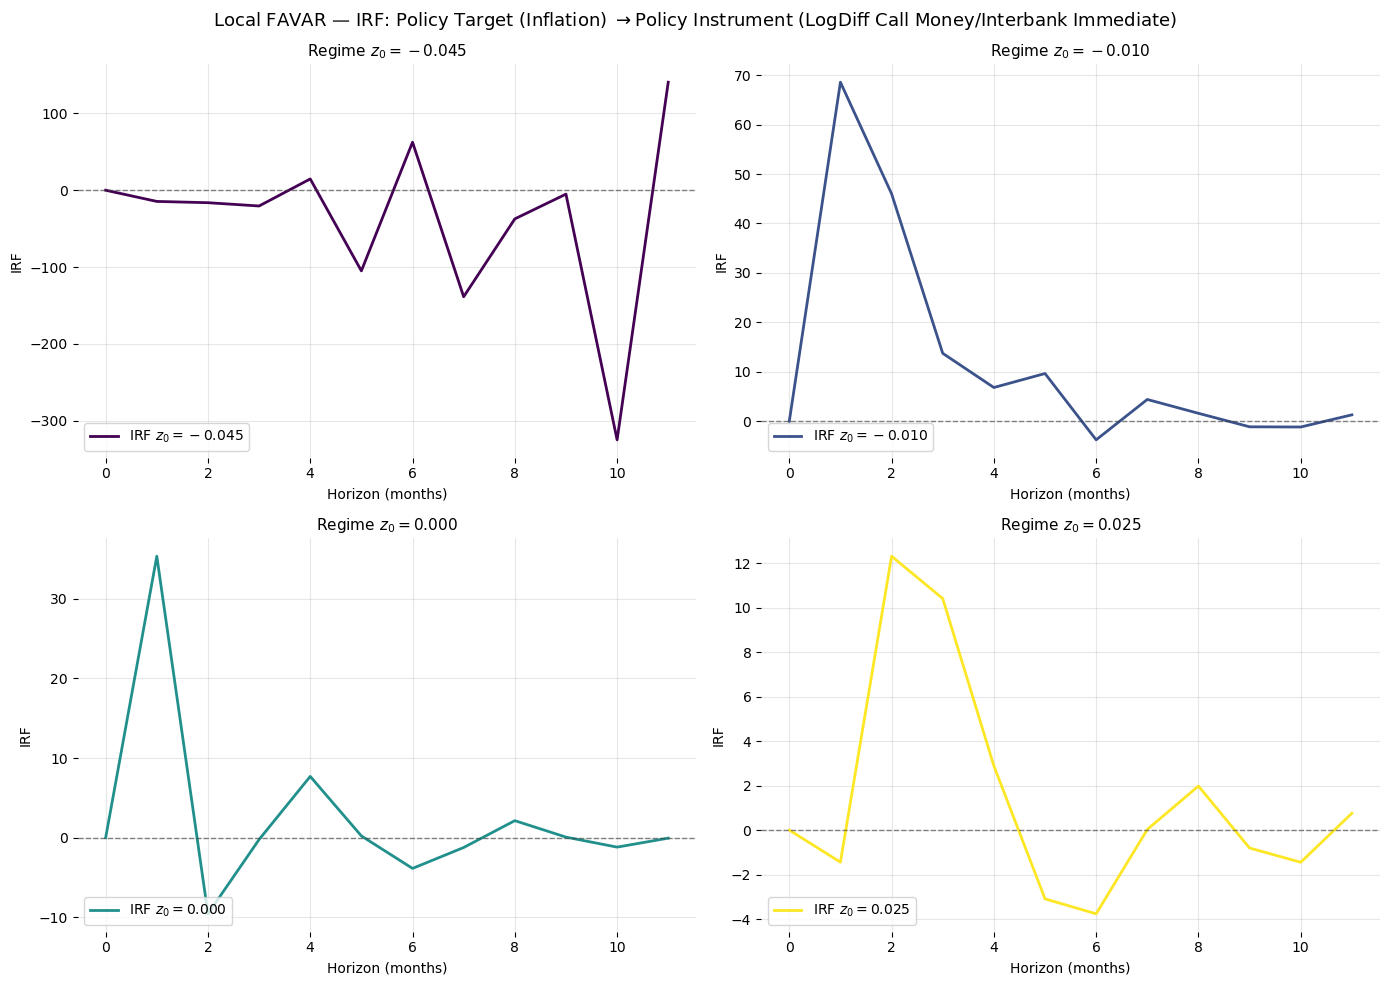

In [54]:
# Local FAVAR Regime Dependent IRF Plotting

# General settings
palette = ["#440154", "#3B528B", "#21908C", "#FDE725"]
fig, axs = plt.subplots(2, 2, figsize=(14, 10), facecolor="white")

# Subplot loop
for i, z0 in enumerate(z_grid):
    ax = axs[i//2, i%2]
    color = palette[i]
    h = np.arange(irf_h)
    irf_vals = irfs[z0][:, target_row, shock_col]

# IRF line Plottinhg
    ax.plot(h, irf_vals, linewidth=2, color=color, label=f"IRF $z_0={z0:.3f}$")
# Zero reference line (for the sign flip)
    ax.axhline(0, color="#393939", lw=1, ls="--", alpha=0.6)

# Cosmetics
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Regime $z_0 = {z0:.3f}$", fontsize=11)
    ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("IRF")
    ax.legend(loc="lower left")
fig.suptitle(
    "Local FAVAR — IRF: Policy Target (Inflation) $\\rightarrow$"
    "Policy Instrument (LogDiff Call Money/Interbank Immediate)",
    fontsize=13
)

plt.tight_layout()
plt.show()